<a href="https://colab.research.google.com/github/sandrazsl/guangzhou-re-montecarlo/blob/main/GZ_Commercial_RE_MonteCarlo_SandraZhang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Simulation: Guangzhou Commercial Real Estate Pricing
## Ornstein-Uhlenbeck Process vs. Geometric Brownian Motion

**Sandra Zhang** | July 2026

This project models the price level movements of Guangzhou's commercial retail property market using two stochastic processes: the Ornstein-Uhlenbeck (OU) process as the primary model and Geometric Brownian Motion (GBM) as a comparison model.

**Motivation:** While leading the restructuring of a distressed commercial real estate project in Guangzhou, the valuation relied on the cost approach which is a single point estimate and appropriate for a fire sale where the seller has no pricing power. Working on the deal also made me curious: beyond the single asset, what does the distribution of possible price movements look like in the market the property sits in, and how much does the choice of stochastic model change the risk picture?

**Key findings:**
- The OU process provides a more economically plausible representation of Guangzhou commercial real estate dynamics under the Three Red Lines policy, while GBM serves as a useful benchmark model. This model choice is based on the idea that the Three Red Lines policy and other government measures may encourage prices to move toward a long-run level instead of drifting freely over time.
- GBM projects roughly 5x larger potential price declines than OU at the 95% confidence level (30 index points vs 6 from start).
- A documented sample refresh by the data provider (CREIS) in 2024 Q2 presented a structural break in the data, requiring careful data filtering for valid calibration.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

N_SIMULATIONS = 10000
HORIZON_MONTHS = 24
CONFIDENCE_LEVELS = [0.95, 0.99]
# dt = 1 (monthly time step; omitted from formulas since multiplying by 1 has no effect)

## Data

**Source:** China Index Academy (CREIS) Guangzhou commercial retail property price index. Monthly observations tracking relative price movements across the city's commercial properties.

**Sample refresh issue:** In 2024 Q2, China Index Academy expanded its Guangzhou commercial property sample to include suburban districts, as documented in their *2024上半年中国商铺租金指数研究报告 (H1 2024 China Retail Property Rental Index Research Report)*. This structural change in index composition contributed to a downward level shift that cannot be cleanly separated from the actual price movements. The chart below shows the full data series with the break point marked.

**Calibration window:**
- I excluded data before 2021 because it predates the Three Red Lines policy, which was announced in August 2020. Including pre-policy data would mix two different market regimes and compromise calibration.
- To maintain consistency, this project calibrates on the pre-refresh period only (January 2021 – March 2024, a total of 39 monthly observations). The pre-refresh index mainly reflects core commercial districts. While Huadu district (where R&F restructuring project sits) is not CBD, it is a mid-tier district rather than a rural outlier like Zengcheng or Conghua, making the pre-refresh city-wide data a reasonable proxy. The index level (μ) may not entirely reflect the equilibrium level in Huadu. But how fast prices correct and how much they fluctuate month to month are driven by the same national policy, so those patterns apply across districts.
- I acknowledge that 39 observations is a small sample. But using all 65 observations would mean mixing two different index compositions, which would give wrong parameter estimates no matter how many data points I have. A clean and small dataset is better than a large contaminated one.
- I chose a 24-month projection horizon because it is proportionate to the 39-month calibration data. Projecting further, for example 36 months, would mean forecasting nearly as far as the data used to fit the model, which reduces reliability.

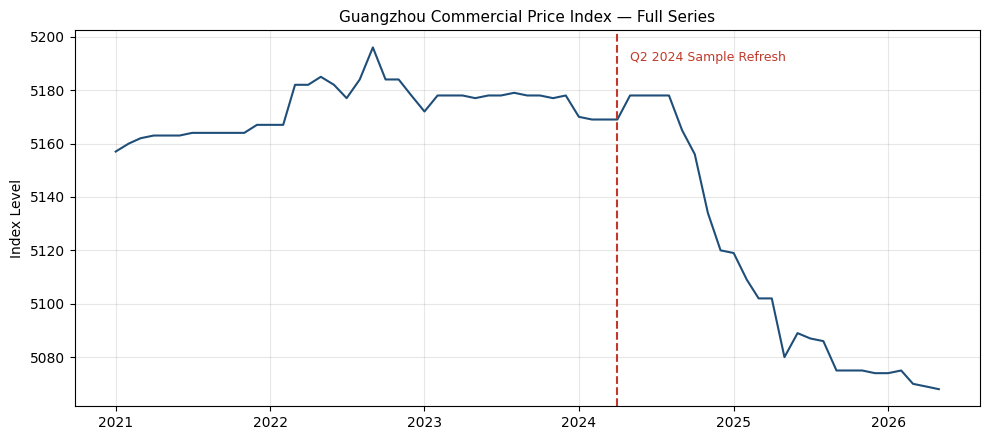

In [ ]:
df_full = pd.read_excel('GZ_RE_data.xlsx', sheet_name='RetailPriceIndex')

plt.figure(figsize=(10, 4.5))
plt.plot(df_full['date'], df_full['price_index'], color='#1f4e79', linewidth=1.5)
plt.axvline(pd.Timestamp('2024-04-01'), color='#c0392b', linestyle='--', linewidth=1.5)
plt.text(pd.Timestamp('2024-05-01'), df_full['price_index'].max() - 5,
         'Q2 2024 Sample Refresh', color='#c0392b', fontsize=9)
plt.title('Guangzhou Commercial Price Index — Full Series', fontsize=11)
plt.ylabel('Index Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df = df_full[df_full['date'] < '2024-04-01'].reset_index(drop=True)

prices = df['price_index'].values
dates = df['date'].values
n_obs = len(prices)

print(f"Calibration series: {n_obs} monthly observations")
print(f"Period: {pd.Timestamp(dates[0]).strftime('%Y-%m')} to "
      f"{pd.Timestamp(dates[-1]).strftime('%Y-%m')}")
print(f"Start: {prices[0]:.2f}  End: {prices[-1]:.2f}")
print(f"Min: {prices.min():.2f}  Max: {prices.max():.2f}")

Calibration series: 39 monthly observations
Period: 2021-01 to 2024-03
Start: 5157.00  End: 5169.00
Min: 5157.00  Max: 5196.00


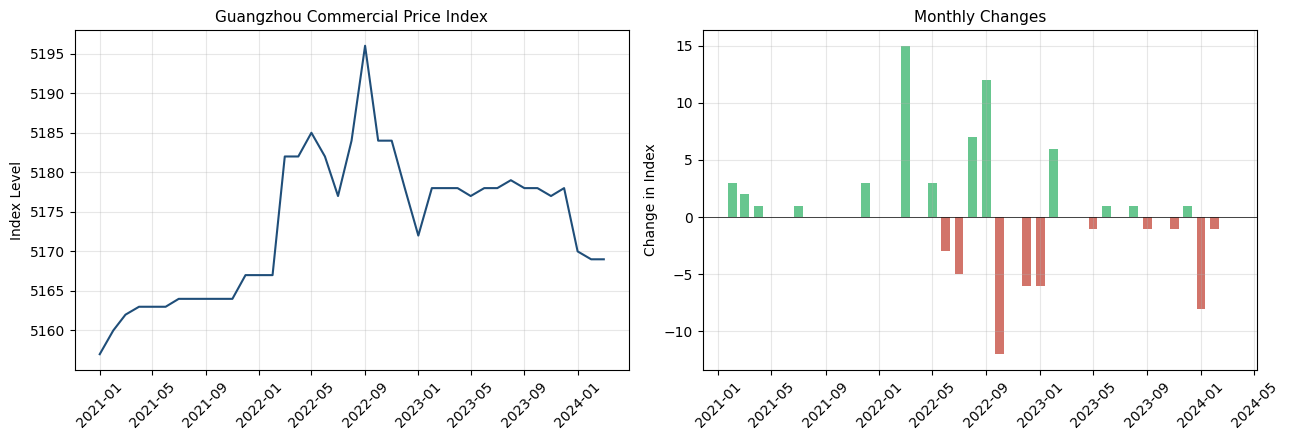

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(dates, prices, color='#1f4e79', linewidth=1.5)
axes[0].set_title('Guangzhou Commercial Price Index', fontsize=11)
axes[0].set_ylabel('Index Level')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

changes = np.diff(prices)

bar_dates = pd.to_datetime(dates[1:])
bar_colors = ['#c0392b' if c < 0 else '#27ae60' for c in changes]
axes[1].bar(bar_dates, changes, width=20, color=bar_colors, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Monthly Changes', fontsize=11)
axes[1].set_ylabel('Change in Index')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Model Selection

**Primary model — Ornstein-Uhlenbeck (OU) process:** The OU process assumes prices get pulled back toward a long-run equilibrium. This fits Guangzhou commercial real estate under the Three Red Lines policy. The policy cuts off developer financing, which forces distressed sales and pushes prices down. At the same time, developers can't fund new projects, so supply dries up and prices can't stay low forever. The government also steps in to prevent prices from falling too far by relaxing purchase restrictions and cutting mortgage rates. The net result: prices can move away from equilibrium, but they keep getting pulled back. This is what mean reversion captures.

**Comparison model — Geometric Brownian Motion (GBM):** GBM treats each month's price change as permanent. Prices move up and down randomly, but there is no equilibrium pulling them back. A drop today becomes the new starting point for tomorrow's random move. This is how stock prices are usually modeled, but it ignores the policy forces that constrain this real estate market.

**Why compare both:** Both models use the same data and the same starting price. The only difference is the structural assumption — does the market revert to an equilibrium, or not? The comparison shows how much that single assumption (mean reversion or not) changes the risk estimate.

**Calibration approach:** OU is calibrated by regressing each month's price on the previous month's price. The slope, intercept, and residuals from that regression give us the OU parameters directly. GBM is calibrated from the average and standard deviation of monthly log returns.

In [ ]:
Y = prices[1:]   # Next month's prices 2-39 months
X = prices[:-1]  # This month's prices 1-38 months

slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
phi_hat = slope
c_hat = intercept
residuals = Y - (c_hat + phi_hat * X)
sigma_eps = np.std(residuals)

theta_hat = -np.log(phi_hat)
mu_hat = c_hat / (1 - phi_hat)
sigma_hat = sigma_eps * np.sqrt(2 * theta_hat / (1 - phi_hat**2))

print("=== OU Parameters ===")
print(f"  theta (mean-reversion speed): {theta_hat:.4f} /month")
print(f"  mu    (long-run mean):        {mu_hat:.2f}")
print(f"  sigma (diffusion):            {sigma_hat:.4f} /month")
print(f"  phi   (AR(1) coefficient):    {phi_hat:.4f}")
print(f"  R-squared:                    {r_value**2:.4f}")
print(f"  Residual std:                 {sigma_eps:.4f}")

# X(t+1) - mu = phi * (X(t)-mu) + noise. Phi tells what fraction of deviation of this month carries into next month.
# Phi is between 0 and 1. Mean reversion is presented in the data. If phi > 1, deviation grows and prices steer away from the mean.
# Theta (mean-reversion speed) is reasonable. Very large values (>10) would mean almost instant reversion, which is unrealistic. Very small values (<0.1) mean weak reversion, making OU similar to GBM.

=== OU Parameters ===
  theta (mean-reversion speed): 0.1966 /month
  mu    (long-run mean):        5175.22
  sigma (diffusion):            4.7528 /month
  phi   (AR(1) coefficient):    0.8215
  R-squared:                    0.7382
  Residual std:                 4.3216


In [ ]:
log_returns = np.log(prices[1:] / prices[:-1])
mu_log = np.mean(log_returns)
sigma_log = np.std(log_returns)

print("=== GBM Parameters ===")
print(f"  Mean log return (monthly): {mu_log:.6f}")
print(f"  Volatility (monthly):      {sigma_log:.6f}")

=== GBM Parameters ===
  Mean log return (monthly): 0.000061
  Volatility (monthly):      0.000888


## Simulation

Both models simulate 10,000 price paths over a 24-month horizon, starting from the last observed pre-refresh index value (March 2024). Each path represents one possible future for Guangzhou commercial property price levels under that model's assumptions.

**OU exact discrete solution:**

$$X_{t+1} = \mu + (X_t - \mu) \cdot e^{-\theta} + \sigma\sqrt{\frac{1 - e^{-2\theta}}{2\theta}} \cdot Z_t$$

- $\theta$ — mean-reversion speed: how fast prices are pulled back toward equilibrium
- $\mu$ — long-run equilibrium price level
- $\sigma$ — how much prices fluctuate randomly each month

**Simulation uses the equivalent AR(1) form:**

$$X_{t+1} = c + \phi \cdot X_t + \sigma_\varepsilon \cdot Z_t$$

The calibration parameters map to the exact solution as follows:
- $\phi = e^{-\theta}$
- $c = \mu(1 - \phi)$
- $\sigma_\varepsilon = \sigma\sqrt{(1 - \phi^2) / 2\theta}$

**GBM exact discrete solution:**

$$S_{t+1} = S_t \cdot \exp\left((\mu_{gbm} - \tfrac{\sigma_{gbm}^2}{2}) \cdot \Delta t + \sigma_{gbm} \cdot \sqrt{\Delta t} \cdot Z_t\right)$$

- $\mu_{gbm}$ — drift: expected growth rate
- $\sigma_{gbm}$ — volatility

**With monthly data ($\Delta t = 1$ month), the calibration parameters map directly:**
- $\mu_{log} = \mu_{gbm} - \sigma_{gbm}^2/2$ — mean of monthly log returns equals the drift minus the Itô correction
- $\sigma_{log} = \sigma_{gbm}$ — standard deviation of monthly log returns equals the volatility parameter since dt=1

**GBM simulation formula simplifies to:**

$$S_{t+1} = S_t \cdot \exp(\mu_{log} + \sigma_{log} \cdot Z_t)$$

$Z_t$ in both models is a standard normal random draw. The same random seed is used throughout for reproducibility.

In [ ]:
X0 = prices[-1]

ou_paths = np.zeros((N_SIMULATIONS, HORIZON_MONTHS + 1))
ou_paths[:, 0] = X0

Z_ou = np.random.standard_normal((N_SIMULATIONS, HORIZON_MONTHS))

for t in range(HORIZON_MONTHS):
    ou_paths[:, t + 1] = c_hat + phi_hat * ou_paths[:, t] + sigma_eps * Z_ou[:, t]

print(f"=== OU Simulation Complete ===")
print(f"  Paths: {N_SIMULATIONS:,}")
print(f"  Horizon: {HORIZON_MONTHS} months")
print(f"  Starting value: {X0:.2f}")
print(f"  Terminal mean: {ou_paths[:, -1].mean():.2f}")
print(f"  Terminal std:  {ou_paths[:, -1].std():.2f}")

=== OU Simulation Complete ===
  Paths: 10,000
  Horizon: 24 months
  Starting value: 5169.00
  Terminal mean: 5175.20
  Terminal std:  7.64


In [ ]:
gbm_paths = np.zeros((N_SIMULATIONS, HORIZON_MONTHS + 1))
gbm_paths[:, 0] = X0

Z_gbm = np.random.standard_normal((N_SIMULATIONS, HORIZON_MONTHS))

monthly_returns = np.exp(mu_log + sigma_log * Z_gbm)

gbm_paths[:, 1:] = X0 * np.cumprod(monthly_returns, axis=1)

print(f"=== GBM Simulation Complete ===")
print(f"  Terminal mean: {gbm_paths[:, -1].mean():.2f}")
print(f"  Terminal std:  {gbm_paths[:, -1].std():.2f}")

=== GBM Simulation Complete ===
  Terminal mean: 5176.28
  Terminal std:  22.50


## Risk Metrics

Two tail risk measures are computed from the 10,000 terminal price index values at month 24:

**Value at Risk (VaR):** The price level that only 5% (or 1%) of simulations fall below. It answers: how bad could things get?

**Expected Shortfall (ES):** The average price level among those worst 5% (or 1%) of outcomes. It answers: when things go bad, how bad on average?

Both are computed at 95% and 99% confidence levels for each model. Comparing the two models on the same data shows how much the mean reversion assumption alone changes the risk picture.

In [ ]:
def compute_risk_metrics(terminal_values, confidence_levels):
    results = {}
    for alpha in confidence_levels:
        var = np.percentile(terminal_values, (1 - alpha) * 100)
        tail_values = terminal_values[terminal_values <= var]
        es = tail_values.mean()
        results[alpha] = {'VaR': var, 'ES': es}
    return results

ou_terminal = ou_paths[:, -1]
gbm_terminal = gbm_paths[:, -1]

ou_risk = compute_risk_metrics(ou_terminal, CONFIDENCE_LEVELS)
gbm_risk = compute_risk_metrics(gbm_terminal, CONFIDENCE_LEVELS)

print(f"=== Risk Metrics (Terminal Values at Month {HORIZON_MONTHS}) ===")
for alpha in CONFIDENCE_LEVELS:
    pct = int(alpha * 100)
    print(f"\n  {pct}% Confidence Level:")
    print(f"    OU  — VaR: {ou_risk[alpha]['VaR']:.2f}  ES: {ou_risk[alpha]['ES']:.2f}")
    print(f"    GBM — VaR: {gbm_risk[alpha]['VaR']:.2f}  ES: {gbm_risk[alpha]['ES']:.2f}")

=== Risk Metrics (Terminal Values at Month 24) ===

  95% Confidence Level:
    OU  — VaR: 5162.67  ES: 5159.46
    GBM — VaR: 5139.05  ES: 5129.79

  99% Confidence Level:
    OU  — VaR: 5157.58  ES: 5154.99
    GBM — VaR: 5124.01  ES: 5116.41


## Results

The following graphs compare the two models:

**Fan charts:** Show the range of simulated price paths over 24 months. The darkest band covers the middle 50% of outcomes (25th–75th percentile), the medium band covers 80% (10th–90th), and the lightest band covers 90% (5th–95th). If the fan chart stops widening, it means the model is pulling prices back. If it keeps spreading, prices are drifting without constraint.

**Terminal distributions:** Histograms of all 10000 final prices at month 24, with VaR and ES lines marked. A tall narrow histogram means outcomes are tightly concentrated around the mean. A short wide histogram means outcomes are spread out with more probability in the tails.

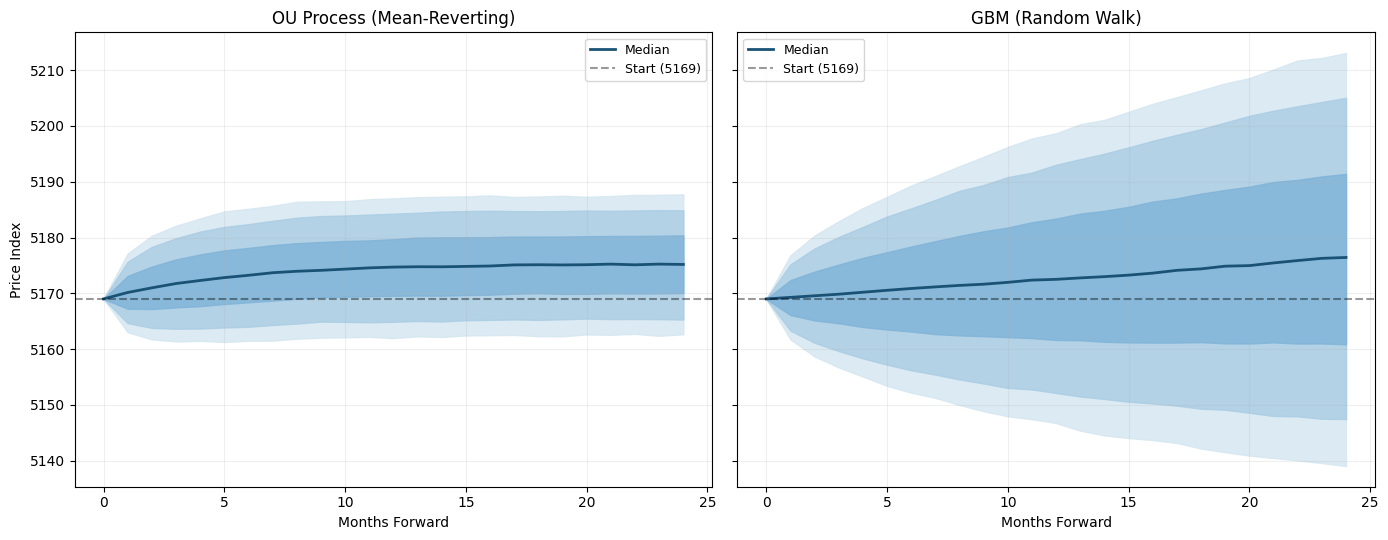

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

future_months = np.arange(HORIZON_MONTHS + 1)
percentiles = [5, 10, 25, 50, 75, 90, 95]
colors_fill = ['#d4e6f1', '#a9cce3', '#7fb3d8']

# Left chart - OU
bands_ou = np.percentile(ou_paths, percentiles, axis=0)
for i in range(3):
    axes[0].fill_between(future_months, bands_ou[i], bands_ou[-(i + 1)],
                         color=colors_fill[i], alpha=0.8)
axes[0].plot(future_months, bands_ou[3], color='#1a5276', linewidth=2, label='Median')
axes[0].axhline(X0, color='black', linestyle='--', alpha=0.4, label=f'Start ({X0:.0f})')
axes[0].set_title('OU Process (Mean-Reverting)', fontsize=12)
axes[0].set_xlabel('Months Forward')
axes[0].set_ylabel('Price Index')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right chart — GBM
bands_gbm = np.percentile(gbm_paths, percentiles, axis=0)
for i in range(3):
    axes[1].fill_between(future_months, bands_gbm[i], bands_gbm[-(i + 1)],
                         color=colors_fill[i], alpha=0.8)
axes[1].plot(future_months, bands_gbm[3], color='#1a5276', linewidth=2, label='Median')
axes[1].axhline(X0, color='black', linestyle='--', alpha=0.4, label=f'Start ({X0:.0f})')
axes[1].set_title('GBM (Random Walk)', fontsize=12)
axes[1].set_xlabel('Months Forward')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

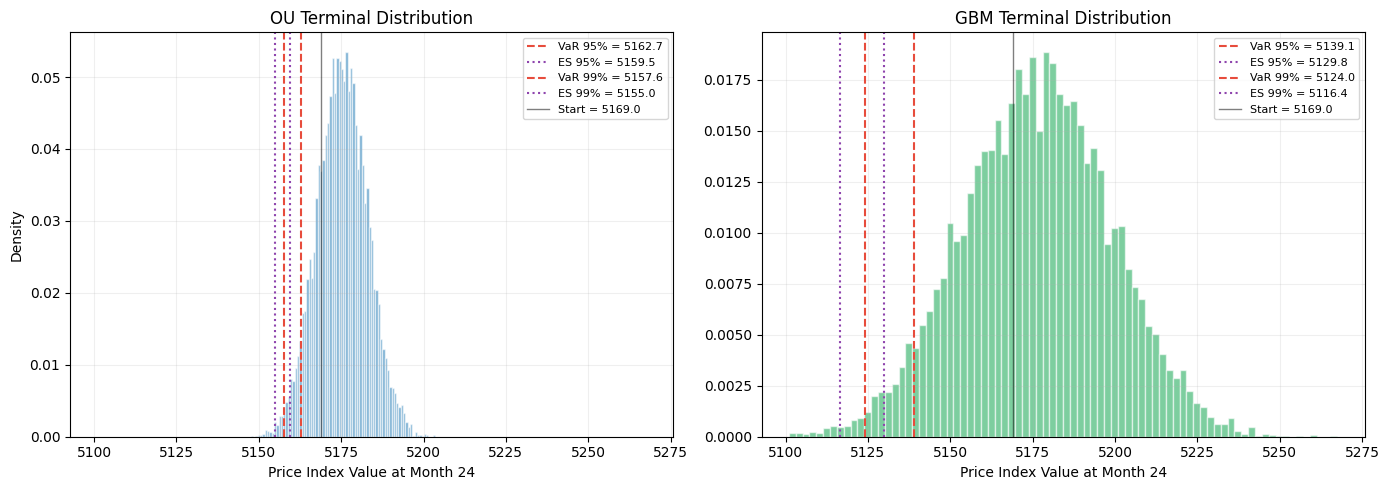

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Left — OU
axes[0].hist(ou_terminal, bins=80, density=True, color='#2980b9', alpha=0.6, edgecolor='white')
for alpha in CONFIDENCE_LEVELS:
    pct = int(alpha * 100)
    axes[0].axvline(ou_risk[alpha]['VaR'], color='#e74c3c', linestyle='--', linewidth=1.5,
                    label=f'VaR {pct}% = {ou_risk[alpha]["VaR"]:.1f}')
    axes[0].axvline(ou_risk[alpha]['ES'], color='#8e44ad', linestyle=':', linewidth=1.5,
                    label=f'ES {pct}% = {ou_risk[alpha]["ES"]:.1f}')
axes[0].axvline(X0, color='black', linestyle='-', linewidth=1, alpha=0.5, label=f'Start = {X0:.1f}')
axes[0].set_title('OU Terminal Distribution', fontsize=12)
axes[0].set_xlabel(f'Price Index Value at Month {HORIZON_MONTHS}')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Right — GBM
axes[1].hist(gbm_terminal, bins=80, density=True, color='#27ae60', alpha=0.6, edgecolor='white')
for alpha in CONFIDENCE_LEVELS:
    pct = int(alpha * 100)
    axes[1].axvline(gbm_risk[alpha]['VaR'], color='#e74c3c', linestyle='--', linewidth=1.5,
                    label=f'VaR {pct}% = {gbm_risk[alpha]["VaR"]:.1f}')
    axes[1].axvline(gbm_risk[alpha]['ES'], color='#8e44ad', linestyle=':', linewidth=1.5,
                    label=f'ES {pct}% = {gbm_risk[alpha]["ES"]:.1f}')
axes[1].axvline(X0, color='black', linestyle='-', linewidth=1, alpha=0.5, label=f'Start = {X0:.1f}')
axes[1].set_title('GBM Terminal Distribution', fontsize=12)
axes[1].set_xlabel(f'Price Index Value at Month {HORIZON_MONTHS}')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 65)
print("  MONTE CARLO SIMULATION SUMMARY")
print("=" * 65)
print(f"  Data:           Guangzhou Retail Price Index")
print(f"  Observations:   {n_obs} monthly (pre-Q2 2024 sample refresh)")
print(f"  Period:         {pd.Timestamp(dates[0]).strftime('%Y-%m')} to "
      f"{pd.Timestamp(dates[-1]).strftime('%Y-%m')}")
print(f"  Starting value: {X0:.2f}")
print(f"  Simulations:    {N_SIMULATIONS:,}")
print(f"  Horizon:        {HORIZON_MONTHS} months")
print("-" * 65)
print(f"\n  OU Parameters:")
print(f"    theta = {theta_hat:.4f}/month  |  mu = {mu_hat:.2f}  |  "
      f"sigma = {sigma_hat:.4f}/month")
print(f"    phi = {phi_hat:.4f}  |  R-squared = {r_value**2:.4f}")
print(f"\n  GBM Parameters:")
print(f"    mu_log = {mu_log:.6f}/month  |  sigma_log = {sigma_log:.6f}/month")
print("-" * 65)
print(f"\n  Terminal Statistics (Month {HORIZON_MONTHS}):")
print(f"    OU  — Mean: {ou_terminal.mean():.2f}  Median: {np.median(ou_terminal):.2f}  Std: {ou_terminal.std():.2f}")
print(f"    GBM — Mean: {gbm_terminal.mean():.2f}  Median: {np.median(gbm_terminal):.2f}  Std: {gbm_terminal.std():.2f}")
print("-" * 65)
print(f"\n  Risk Metrics:")
for alpha in CONFIDENCE_LEVELS:
    pct = int(alpha * 100)
    print(f"    VaR {pct}%:   OU = {ou_risk[alpha]['VaR']:.2f}  |  "
          f"GBM = {gbm_risk[alpha]['VaR']:.2f}")
    print(f"    ES  {pct}%:   OU = {ou_risk[alpha]['ES']:.2f}  |  "
          f"GBM = {gbm_risk[alpha]['ES']:.2f}")
print("=" * 65)

  MONTE CARLO SIMULATION SUMMARY
  Data:           Guangzhou Retail Price Index
  Observations:   39 monthly (pre-Q2 2024 sample refresh)
  Period:         2021-01 to 2024-03
  Starting value: 5169.00
  Simulations:    10,000
  Horizon:        24 months
-----------------------------------------------------------------

  OU Parameters:
    theta = 0.1966/month  |  mu = 5175.22  |  sigma = 4.7528/month
    phi = 0.8215  |  R-squared = 0.7382

  GBM Parameters:
    mu_log = 0.000061/month  |  sigma_log = 0.000888/month
-----------------------------------------------------------------

  Terminal Statistics (Month 24):
    OU  — Mean: 5175.20  Median: 5175.18  Std: 7.64
    GBM — Mean: 5176.28  Median: 5176.43  Std: 22.50
-----------------------------------------------------------------

  Risk Metrics:
    VaR 95%:   OU = 5162.67  |  GBM = 5139.05
    ES  95%:   OU = 5159.46  |  GBM = 5129.79
    VaR 99%:   OU = 5157.58  |  GBM = 5124.01
    ES  99%:   OU = 5154.99  |  GBM = 5116.41


## Conclusions

**OU is a more appropriate model for this market than GBM:** The model selection rationale is discussed above. The data is consistent with it: the index rose from 5157 to 5196 in mid 2022, then gradually fell back to 5169 by March 2024 — pulled back toward the calibrated equilibrium of 5175. While GBM can generate similar corrections by chance, unlike OU it does not contain an explicit mechanism that pulls prices toward a long-run equilibrium.

**Model choice changes the risk picture:** With same data and same starting point, OU says there's a 95% probability that prices wouldn't decline more than 0.12% ((5169 − 5162.67) / 5169) over 24 months. GBM says 0.57% ((5169 − 5139.05) / 5169). Both are small in absolute terms, but GBM's estimate is roughly 5x larger.

**What the data tells us about this market:**
- Price levels are policy-stabilized and likely to stay in a narrow range. The correction from the 5196 peak to the 5175 equilibrium was gradual (21 points over 10 months). Month to month fluctuations are less than 0.1%, consistent with a market where new supply is constrained by financing restrictions and demand is weak. Projecting 24 months forward, OU estimates prices would settle near 5175, with at most a 0.12% decline even in a bad scenario. Three Red Lines doesn't cause crashes; it constrains supply while weak demand limits upward pressure, keeping price levels stable.

- The real risk may not be price. The city-wide price index was stable, but city-wide clearance periods have surged from around 55 months in early 2024 to over 150 months by late 2025, meaning it would take over 12 years to sell the existing inventory at current transaction rates. Huadu district is even worse, with clearance periods exceeding 300 months. The few deals that happen still close at normal prices, so the price index looks stable. But the market is frozen. For distressed assets like the R&F project, the bigger threat is not a price drop but the inability to sell at all. This project measures price risk. Liquidity risk is a separate and equally important question.

**Limitations:**
- 39 observations is a small sample. The calibrated parameters are less precise than a longer data series would give.
- The index reflects core commercial districts, not Huadu specifically. How fast prices correct (θ) and how much they fluctuate (σ) are more transferable across districts than the absolute equilibrium level (μ), but the match is imperfect.
- Both models assume monthly price changes follow a normal distribution. Neither captures sudden large jumps from unexpected events or market shocks.
- This project models market-level price movements, not the value of a specific property. Going from market-level trends to an actual property valuation would require additional property-level information, which is outside the scope of this project.